Imports & folder setup

In [1]:
import os
import glob
import duckdb
import numpy as np
import pandas as pd

folder = r"C:\Users\wandy\OneDrive\Desktop\Users\DELL\OneDrive - Southampton Solent University\Placement\Dissertation\Datasets\Dissertation Datasets Jupyter"

con = duckdb.connect()


MIMIC-IV ANALYTIC DATASET  (clinical cohort, comorbidities, outcomes)

In [2]:
labs_raw = con.execute(f"""
SELECT
    hadm_id,
    valuenum
FROM read_csv_auto('{folder}\\labevents.csv.gz')
""").fetchdf()

labs = labs_raw.groupby("hadm_id").agg(
    lab_count=("valuenum", "count"),
    abnormal_labs=("valuenum", lambda x: ((x < 0) | (x > 1000)).sum())
).reset_index()

labs.to_parquet(os.path.join(folder, "labs.parquet"))
print("Saved labs.parquet")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved labs.parquet


In [3]:
pharm_raw = con.execute(f"""
SELECT
    hadm_id,
    pharmacy_id
FROM read_csv_auto('{folder}\\pharmacy.csv.gz')
""").fetchdf()

pharm = pharm_raw.groupby("hadm_id").agg(
    med_count=("pharmacy_id", "nunique")
).reset_index()

pharm.to_parquet(os.path.join(folder, "pharm.parquet"))
print("Saved pharm.parquet")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved pharm.parquet


In [4]:
presc_raw = con.execute(f"""
SELECT
    hadm_id,
    drug
FROM read_csv_auto('{folder}\\prescriptions.csv.gz')
""").fetchdf()

presc = presc_raw.groupby("hadm_id").agg(
    unique_drugs=("drug", "nunique")
).reset_index()

presc.to_parquet(os.path.join(folder, "prescriptions.parquet"))
print("Saved prescriptions.parquet")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved prescriptions.parquet


In [5]:
poe_raw = con.execute(f"""
SELECT
    hadm_id
FROM read_csv_auto('{folder}\\poe.csv.gz')
""").fetchdf()

poe = poe_raw.groupby("hadm_id").agg(
    admin_events=("hadm_id", "count")
).reset_index()

poe.to_parquet(os.path.join(folder, "poe.parquet"))
print("Saved poe.parquet")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved poe.parquet


In [6]:
# 1.1 Base adult cohort (admissions + patients)
cohort = con.execute(f"""
WITH base AS (
    SELECT
        adm.subject_id,
        adm.hadm_id,
        adm.admittime,
        adm.dischtime,
        adm.admission_type,
        pat.anchor_age AS age
    FROM read_csv_auto('{folder}\\admissions.csv.gz') adm
    JOIN read_csv_auto('{folder}\\patients.csv.gz') pat
        ON adm.subject_id = pat.subject_id
    WHERE pat.anchor_age >= 18
      AND adm.dischtime IS NOT NULL
)
SELECT * FROM base
""").fetchdf()


In [7]:
# 1.2 ICU stays
icu = con.execute(f"""
SELECT
    icu.subject_id,
    icu.hadm_id,
    icu.stay_id,
    icu.intime AS icu_intime,
    icu.outtime AS icu_outtime,
    icu.first_careunit
FROM read_csv_auto('{folder}\\icustays.csv.gz') icu
""").fetchdf()


In [8]:
# 1.3 Cohort + ICU (ever_in_icu flag)
cohort_icu = con.execute(f"""
SELECT
    b.*,
    icu.intime AS icu_intime,
    icu.outtime AS icu_outtime,
    icu.first_careunit,
    CASE WHEN icu.hadm_id IS NOT NULL THEN 1 ELSE 0 END AS ever_in_icu
FROM (
    SELECT
        adm.subject_id,
        adm.hadm_id,
        adm.admittime,
        adm.dischtime,
        adm.admission_type,
        pat.anchor_age AS age
    FROM read_csv_auto('{folder}\\admissions.csv.gz') adm
    JOIN read_csv_auto('{folder}\\patients.csv.gz') pat
        ON adm.subject_id = pat.subject_id
    WHERE pat.anchor_age >= 18
      AND adm.dischtime IS NOT NULL
) b
LEFT JOIN read_csv_auto('{folder}\\icustays.csv.gz') icu
    ON b.hadm_id = icu.hadm_id
""").fetchdf()


In [9]:
# 1.4 Diagnoses + full cohort
diagnoses = con.execute(f"""
SELECT
    d.subject_id,
    d.hadm_id,
    d.icd_code,
    d.icd_version
FROM read_csv_auto('{folder}\\diagnoses_icd.csv.gz') d
""").fetchdf()

cohort_full = con.execute(f"""
SELECT
    c.*,
    d.icd_code,
    d.icd_version
FROM (
    SELECT
        b.*,
        icu.intime AS icu_intime,
        icu.outtime AS icu_outtime,
        icu.first_careunit,
        CASE WHEN icu.hadm_id IS NOT NULL THEN 1 ELSE 0 END AS ever_in_icu
    FROM (
        SELECT
            adm.subject_id,
            adm.hadm_id,
            adm.admittime,
            adm.dischtime,
            adm.admission_type,
            pat.anchor_age AS age
        FROM read_csv_auto('{folder}\\admissions.csv.gz') adm
        JOIN read_csv_auto('{folder}\\patients.csv.gz') pat
            ON adm.subject_id = pat.subject_id
        WHERE pat.anchor_age >= 18
          AND adm.dischtime IS NOT NULL
    ) b
    LEFT JOIN read_csv_auto('{folder}\\icustays.csv.gz') icu
        ON b.hadm_id = icu.hadm_id
) c
LEFT JOIN read_csv_auto('{folder}\\diagnoses_icd.csv.gz') d
    ON c.hadm_id = d.hadm_id
""").fetchdf()

# LOS in hours/days
cohort_full["los_hours"] = (
    cohort_full["dischtime"] - cohort_full["admittime"]
).dt.total_seconds() / 3600
cohort_full["los_days"] = cohort_full["los_hours"] / 24


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [10]:
# 1.5 Comorbidities (ICD-based flags)
comorbidities = con.execute(f"""
WITH dx AS (
    SELECT
        hadm_id,
        icd_code,
        icd_version
    FROM read_csv_auto('{folder}\\diagnoses_icd.csv.gz')
),
flags AS (
    SELECT
        hadm_id,

        MAX(CASE WHEN icd_code LIKE 'I50%' THEN 1 ELSE 0 END) AS chf,
        MAX(CASE WHEN icd_code LIKE 'E10%' OR icd_code LIKE 'E11%' OR
                       icd_code LIKE 'E13%' OR icd_code LIKE 'E14%'
                 THEN 1 ELSE 0 END) AS diabetes,
        MAX(CASE WHEN icd_code LIKE 'J44%' OR icd_code LIKE 'J45%'
                 THEN 1 ELSE 0 END) AS copd,
        MAX(CASE WHEN icd_code LIKE 'N18%' OR icd_code LIKE 'N19%'
                 THEN 1 ELSE 0 END) AS renal_disease,
        MAX(CASE WHEN icd_code LIKE 'C0%' OR icd_code LIKE 'C1%' OR
                       icd_code LIKE 'C2%' OR icd_code LIKE 'C3%' OR
                       icd_code LIKE 'C4%' OR icd_code LIKE 'C5%' OR
                       icd_code LIKE 'C6%'
                 THEN 1 ELSE 0 END) AS malignancy
    FROM dx
    GROUP BY hadm_id
)
SELECT * FROM flags
""").fetchdf()

comorbidities["charlson_like"] = (
    1 * comorbidities["chf"]
    + 1 * comorbidities["diabetes"]
    + 1 * comorbidities["copd"]
    + 2 * comorbidities["renal_disease"]
    + 2 * comorbidities["malignancy"]
)

comorbidities["elixhauser_like"] = (
    comorbidities[["chf", "diabetes", "copd", "renal_disease", "malignancy"]]
    .sum(axis=1)
)



In [11]:
labs = pd.read_parquet(os.path.join(folder, "labs.parquet"))
pharm = pd.read_parquet(os.path.join(folder, "pharm.parquet"))
presc = pd.read_parquet(os.path.join(folder, "prescriptions.parquet"))
poe = pd.read_parquet(os.path.join(folder, "poe.parquet"))

In [12]:
labs = con.execute(f"""
SELECT
    hadm_id,
    COUNT(*) AS lab_count,
    SUM(
        CASE WHEN valuenum IS NULL THEN 0
             WHEN valuenum < 0 THEN 1
             WHEN valuenum > 1000 THEN 1
             ELSE 0 END
    ) AS abnormal_labs
FROM read_csv_auto('{folder}\\labevents.csv.gz')
GROUP BY hadm_id
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [13]:
pharm = con.execute(f"""
SELECT
    hadm_id,
    COUNT(DISTINCT pharmacy_id) AS med_count
FROM read_csv_auto('{folder}\\pharmacy.csv.gz')
GROUP BY hadm_id
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [14]:
presc = con.execute(f"""
SELECT
    hadm_id,
    COUNT(DISTINCT drug) AS unique_drugs
FROM read_csv_auto('{folder}\\prescriptions.csv.gz')
GROUP BY hadm_id
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [15]:
poe = con.execute(f"""
SELECT
    hadm_id,
    COUNT(*) AS admin_events
FROM read_csv_auto('{folder}\\poe.csv.gz')
GROUP BY hadm_id
""").fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [16]:
# 1.6 Readmission (30-day)
admissions = con.execute(f"""
    SELECT
        subject_id,
        hadm_id,
        admittime,
        dischtime,
        hospital_expire_flag
    FROM read_csv_auto('{folder}\\admissions.csv.gz')
""").fetchdf()

patients = con.execute(f"""
    SELECT
        subject_id,
        anchor_age,
        dod AS date_of_death
    FROM read_csv_auto('{folder}\\patients.csv.gz')
""").fetchdf()

admissions = admissions.sort_values(by=["subject_id", "admittime"])
admissions["next_admittime"] = admissions.groupby("subject_id")["admittime"].shift(-1)

admissions["days_to_readmit"] = (
    (admissions["next_admittime"] - admissions["dischtime"])
    .dt.total_seconds() / (3600 * 24)
)

admissions["readmit_30d"] = (
    (admissions["days_to_readmit"] >= 0)
    & (admissions["days_to_readmit"] <= 30)
).astype(int)

readmission = admissions[["hadm_id", "readmit_30d"]]

In [17]:
# 1.7 Mortality (in-hospital & 30-day)
admissions["mortality_inhospital"] = admissions["hospital_expire_flag"]

merged = admissions.merge(
    patients[["subject_id", "date_of_death"]],
    on="subject_id",
    how="left",
)

merged["date_of_death"] = pd.to_datetime(merged["date_of_death"])
merged["admittime"] = pd.to_datetime(merged["admittime"])

merged["days_to_death"] = (
    (merged["date_of_death"] - merged["admittime"])
    .dt.total_seconds() / (3600 * 24)
)

merged["mortality_30d"] = (
    (merged["days_to_death"] >= 0)
    & (merged["days_to_death"] <= 30)
).astype(int)

mortality = merged[["hadm_id", "mortality_inhospital", "mortality_30d"]]

In [18]:
analytic_mimic = (
    cohort_full
    .merge(comorbidities, on="hadm_id", how="left")
    .merge(readmission, on="hadm_id", how="left")
    .merge(mortality, on="hadm_id", how="left")
    .merge(labs, on="hadm_id", how="left")
    .merge(pharm, on="hadm_id", how="left")
    .merge(presc, on="hadm_id", how="left")
    .merge(poe, on="hadm_id", how="left")
)

In [19]:
# 1.8 Final MIMIC analytic dataset
analytic_mimic = analytic_mimic.fillna({
    "chf": 0,
    "diabetes": 0,
    "copd": 0,
    "renal_disease": 0,
    "malignancy": 0,
    "charlson_like": 0,
    "elixhauser_like": 0,
    "readmit_30d": 0,
    "mortality_inhospital": 0,
    "mortality_30d": 0,
    "lab_count": 0,
    "abnormal_labs": 0,
    "med_count": 0,
    "unique_drugs": 0,
    "admin_events": 0

})

mimic_out_path = os.path.join(folder, "mimic_analytic.parquet")
analytic_mimic.to_parquet(mimic_out_path)

print("MIMIC analytic shape:", analytic_mimic.shape)


MIMIC analytic shape: (6599888, 29)


NHS ANALYTIC DATASET (PCA + SitRep, ready for modelling)

In [20]:
# 2.1 Load all PCA monthly files
pca_files = sorted(glob.glob(os.path.join(folder, "pca_2023*.csv")))
pca_files += sorted(glob.glob(os.path.join(folder, "pca_202312.csv")))  # ensure Dec included

pca_dfs = []
for fpath in pca_files:
    df = pd.read_csv(fpath)
    df["source_file"] = os.path.basename(fpath)
    pca_dfs.append(df)

if pca_dfs:
    pca_all = pd.concat(pca_dfs, ignore_index=True)
else:
    pca_all = pd.DataFrame()

print("PCA combined shape:", pca_all.shape)

# 2.2 Load combined SitRep file
sitrep_path = os.path.join(folder, "sitrep_2023_2024_full.parquet")
sitrep = pd.read_parquet(sitrep_path)
print("SitRep shape:", sitrep.shape)

# NOTE:
# We are not forcing a merge here because the correct key
# (date, trust, period, etc.) is a conceptual decision.
# For now, we keep both clean and ready:
analytic_nhs_pca = pca_all.copy()
analytic_nhs_sitrep = sitrep.copy()

# You can later:
# - merge on date/period/trust if appropriate
# - or model them separately


PCA combined shape: (7451747, 27)
SitRep shape: (1950, 44)


SUMMARY

In [21]:
print("\nSUMMARY")
print("MIMIC analytic dataset:", analytic_mimic.shape)
print("NHS PCA dataset:", analytic_nhs_pca.shape)
print("NHS SitRep dataset:", analytic_nhs_sitrep.shape)


SUMMARY
MIMIC analytic dataset: (6599888, 29)
NHS PCA dataset: (7451747, 27)
NHS SitRep dataset: (1950, 44)


COLLAPSE MIMIC-IV TO ONE ROW PER ADMISSION

In [22]:
# 1. Start from the base cohort (one row per admission)
base = cohort_icu[[
    "subject_id", "hadm_id", "admittime", "dischtime",
    "admission_type", "age", "icu_intime", "icu_outtime",
    "first_careunit", "ever_in_icu"
]].drop_duplicates(subset=["hadm_id"])

# 2. Add comorbidities
base = base.merge(comorbidities, on="hadm_id", how="left")

# 3. Add readmission
base = base.merge(readmission, on="hadm_id", how="left")

# 4. Add mortality
base = base.merge(mortality, on="hadm_id", how="left")

# 5. Add labs/pharmacy/presc/poe (from Parquet)
base = base.merge(labs, on="hadm_id", how="left")
base = base.merge(pharm, on="hadm_id", how="left")
base = base.merge(presc, on="hadm_id", how="left")
base = base.merge(poe, on="hadm_id", how="left")

# 6. Compute LOS
base["los_hours"] = (base["dischtime"] - base["admittime"]).dt.total_seconds() / 3600
base["los_days"] = base["los_hours"] / 24

# 7. Fill missing values
base = base.fillna({
    "chf": 0,
    "diabetes": 0,
    "copd": 0,
    "renal_disease": 0,
    "malignancy": 0,
    "charlson_like": 0,
    "elixhauser_like": 0,
    "readmit_30d": 0,
    "mortality_inhospital": 0,
    "mortality_30d": 0,
    "lab_count": 0,
    "abnormal_labs": 0,
    "med_count": 0,
    "unique_drugs": 0,
    "admin_events": 0
})

# 8. Final analytic dataset
analytic_mimic_final = base.copy()

print("Final MIMIC analytic shape:", analytic_mimic_final.shape)
analytic_mimic_final.head()

Final MIMIC analytic shape: (546028, 27)


,subject_id,hadm_id,admittime,dischtime,admission_type,age,icu_intime,icu_outtime,first_careunit,ever_in_icu,...,readmit_30d,mortality_inhospital,mortality_30d,lab_count,abnormal_labs,med_count,unique_drugs,admin_events,los_hours,los_days
0,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,EW EMER.,52,2180-07-23 14:00:00,2180-07-23 23:50:47,Medical Intensive Care Unit (MICU),1,...,1,0,0,68.0,0.0,24.0,17.0,93.0,53.333333,2.222222
1,10000690,25860671,2150-11-02 18:02:00,2150-11-12 13:45:00,EW EMER.,86,2150-11-02 19:37:00,2150-11-06 17:03:17,Medical Intensive Care Unit (MICU),1,...,0,0,0,255.0,0.0,63.0,37.0,178.0,235.716667,9.821528
2,10000980,26913865,2189-06-27 07:38:00,2189-07-03 03:00:00,EW EMER.,73,2189-06-27 08:42:00,2189-06-27 20:38:27,Medical Intensive Care Unit (MICU),1,...,0,0,0,166.0,0.0,39.0,34.0,150.0,139.366667,5.806944
3,10001217,24597018,2157-11-18 22:56:00,2157-11-25 18:00:00,EW EMER.,55,2157-11-20 19:18:02,2157-11-21 22:08:00,Surgical Intensive Care Unit (SICU),1,...,1,0,0,140.0,0.0,33.0,23.0,141.0,163.066667,6.794444
4,10001217,27703517,2157-12-18 16:58:00,2157-12-24 14:55:00,DIRECT EMER.,55,2157-12-19 15:42:24,2157-12-20 14:27:41,Surgical Intensive Care Unit (SICU),1,...,0,0,0,137.0,0.0,41.0,27.0,109.0,141.950000,5.914583


In [23]:
import pandas as pd

# 1. Load raw analytic dataset (6.5M rows)
df = pd.read_parquet("mimic_analytic.parquet")

# 2. Collapse comorbidity flags + summary scores
diag_cols = ["chf", "diabetes", "copd", "renal_disease", "malignancy",
             "charlson_like", "elixhauser_like"]

diag_agg = df.groupby("hadm_id")[diag_cols].max().reset_index()

# 3. Collapse ICU stays
icu_agg = df.groupby("hadm_id").agg({
    "ever_in_icu": "max",
    "first_careunit": "first"
}).reset_index()

# 4. Extract admission-level fields (already one per admission)
adm_cols = [
    "subject_id", "hadm_id", "admittime", "dischtime",
    "admission_type", "age", "los_hours", "los_days",
    "readmit_30d", "mortality_inhospital", "mortality_30d"
]

adm = df[adm_cols].drop_duplicates(subset="hadm_id")

# 5. Merge everything into one analytic dataset
analytic = adm.merge(diag_agg, on="hadm_id", how="left")
analytic = analytic.merge(icu_agg, on="hadm_id", how="left")

# 6. Clean missing values
# for col in analytic.select_dtypes(include="number").columns:
   # analytic[col] = analytic[col].fillna(analytic[col].median())

# for col in analytic.select_dtypes(include="object").columns:
    # analytic[col] = analytic[col].fillna("Unknown")

# 7. Save final modelling-ready dataset
analytic.to_parquet("mimic_out_path", index=False)

# 8. Confirm shape
print(analytic.shape)
analytic.head()

(546028, 20)


,subject_id,hadm_id,admittime,dischtime,admission_type,age,los_hours,los_days,readmit_30d,mortality_inhospital,mortality_30d,chf,diabetes,copd,renal_disease,malignancy,charlson_like,elixhauser_like,ever_in_icu,first_careunit
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,52,18.866667,0.786111,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,None
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,EW EMER.,52,24.366667,1.015278,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,None
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,EW EMER.,52,42.100000,1.754167,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,None
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,EW EMER.,52,53.333333,2.222222,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Medical Intensive Care Unit (MICU)
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,EU OBSERVATION,19,7.166667,0.298611,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,None


MODELLING-READY PIPELINE

Load the final analytic dataset

READMISSION RISK
{Select predictors and target (include LOS)}

In [24]:
# Keep only relevant columns

# We’ll predict 30‑day readmission using admission‑level features, including LOS

model_df = analytic_mimic_final[[
    "hadm_id",
    "subject_id",
    "age",
    "admission_type",
    "ever_in_icu",
    "charlson_like",
    "elixhauser_like",
    "los_days",
    "lab_count",
    "abnormal_labs",
    "med_count",
    "unique_drugs",
    "admin_events",
    "readmit_30d" 
]].copy()

print(model_df.shape)
model_df.head()

(546028, 14)


,hadm_id,subject_id,age,admission_type,ever_in_icu,charlson_like,elixhauser_like,los_days,lab_count,abnormal_labs,med_count,unique_drugs,admin_events,readmit_30d
0,29079034,10000032,52,EW EMER.,1,0.0,0.0,2.222222,68.0,0.0,24.0,17.0,93.0,1
1,25860671,10000690,86,EW EMER.,1,0.0,0.0,9.821528,255.0,0.0,63.0,37.0,178.0,0
2,26913865,10000980,73,EW EMER.,1,0.0,0.0,5.806944,166.0,0.0,39.0,34.0,150.0,0
3,24597018,10001217,55,EW EMER.,1,0.0,0.0,6.794444,140.0,0.0,33.0,23.0,141.0,1
4,27703517,10001217,55,DIRECT EMER.,1,0.0,0.0,5.914583,137.0,0.0,41.0,27.0,109.0,0


Handle missing values

In [25]:
# Numeric → median
for col in model_df.select_dtypes(include="number").columns:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Categorical → "Unknown"
for col in model_df.select_dtypes(include="object").columns:
    model_df[col] = model_df[col].fillna("Unknown")

model_df.isna().sum()

hadm_id            0
subject_id         0
age                0
admission_type     0
ever_in_icu        0
charlson_like      0
elixhauser_like    0
los_days           0
lab_count          0
abnormal_labs      0
med_count          0
unique_drugs       0
admin_events       0
readmit_30d        0
dtype: int64

Encode categorical variables

In [26]:
categorical_cols = ["admission_type"]

model_df = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True
)

print(model_df.columns)

Index(['hadm_id', 'subject_id', 'age', 'ever_in_icu', 'charlson_like',
       'elixhauser_like', 'los_days', 'lab_count', 'abnormal_labs',
       'med_count', 'unique_drugs', 'admin_events', 'readmit_30d',
       'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVATION',
       'admission_type_ELECTIVE', 'admission_type_EU OBSERVATION',
       'admission_type_EW EMER.', 'admission_type_OBSERVATION ADMIT',
       'admission_type_SURGICAL SAME DAY ADMISSION', 'admission_type_URGENT'],
      dtype='object')


In [27]:
model_df.head()

,hadm_id,subject_id,age,ever_in_icu,charlson_like,elixhauser_like,los_days,lab_count,abnormal_labs,med_count,...,admin_events,readmit_30d,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT
0,29079034,10000032,52,1,0.0,0.0,2.222222,68.0,0.0,24.0,...,93.0,1,False,False,False,False,True,False,False,False
1,25860671,10000690,86,1,0.0,0.0,9.821528,255.0,0.0,63.0,...,178.0,0,False,False,False,False,True,False,False,False
2,26913865,10000980,73,1,0.0,0.0,5.806944,166.0,0.0,39.0,...,150.0,0,False,False,False,False,True,False,False,False
3,24597018,10001217,55,1,0.0,0.0,6.794444,140.0,0.0,33.0,...,141.0,1,False,False,False,False,True,False,False,False
4,27703517,10001217,55,1,0.0,0.0,5.914583,137.0,0.0,41.0,...,109.0,0,True,False,False,False,False,False,False,False


Define features and target

In [28]:
X = model_df.drop(columns=["readmit_30d", "hadm_id", "subject_id"])
y = model_df["readmit_30d"]

print(X.shape, y.shape)

(546028, 18) (546028,)


Train/test split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((436822, 18), (109206, 18))

Scale numerical features

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train a baseline logistic regression model

In [31]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

Evaluate performance

In [32]:
from sklearn.metrics import roc_auc_score, classification_report

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.5983288637872592
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     87337
           1       0.45      0.01      0.02     21869

    accuracy                           0.80    109206
   macro avg       0.63      0.50      0.45    109206
weighted avg       0.73      0.80      0.71    109206



In [33]:
log_reg_balanced = LogisticRegression(
    max_iter=500,
    class_weight="balanced"
)

log_reg_balanced.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [34]:
# Train the Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Notice: Random Forest does NOT need scaling, so we use X_train and X_test directly.

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
# Evaluate the Random Forest

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

ROC-AUC: 0.6436994657117254
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     87337
           1       0.58      0.09      0.16     21869

    accuracy                           0.80    109206
   macro avg       0.70      0.54      0.52    109206
weighted avg       0.77      0.80      0.74    109206



In [36]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [37]:
# Evaluate XGBoost

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

ROC-AUC: 0.6667978756868751
              precision    recall  f1-score   support

           0       0.81      0.99      0.89     87337
           1       0.67      0.07      0.13     21869

    accuracy                           0.81    109206
   macro avg       0.74      0.53      0.51    109206
weighted avg       0.78      0.81      0.74    109206



Threshold Tuning for XGBoost

In [38]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.51, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    results.append((t, precision, recall, f1))

results

[(np.float64(0.1), 0.212076319635702, 0.9753532397457588, 0.3483984776962906),
 (np.float64(0.15000000000000002),
  0.24326135617301325,
  0.8298962001005991,
  0.37623865002694973),
 (np.float64(0.20000000000000004),
  0.29451863570797077,
  0.5788559147651927,
  0.39040261522567116),
 (np.float64(0.25000000000000006),
  0.354130282920014,
  0.37089030133979606,
  0.36231657472137224),
 (np.float64(0.30000000000000004),
  0.42188745416865936,
  0.24203210023320681,
  0.30759843091675143),
 (np.float64(0.3500000000000001),
  0.504925746213792,
  0.1570259271114363,
  0.23955354028601325),
 (np.float64(0.40000000000000013),
  0.5814988290398126,
  0.11353971375005716,
  0.18998431462565515),
 (np.float64(0.45000000000000007),
  0.6340916372957386,
  0.09049339247336412,
  0.15838335334133655),
 (np.float64(0.5000000000000001),
  0.6724782067247821,
  0.07407746124651333,
  0.1334541560260318)]

In [ ]:
best_threshold = 0.30
y_pred_opt = (y_prob_xgb >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87     87337
           1       0.42      0.24      0.31     21869

    accuracy                           0.78    109206
   macro avg       0.63      0.58      0.59    109206
weighted avg       0.75      0.78      0.76    109206

ROC-AUC: 0.6667978756868751


In [103]:
# READMISSION DATASET
X_readm = model_df.drop(columns=["readmit_30d", "hadm_id", "subject_id"])
y_readm = model_df["readmit_30d"]

from sklearn.model_selection import train_test_split

X_train_readm, X_test_readm, y_train_readm, y_test_readm = train_test_split(
    X_readm, y_readm, test_size=0.2, random_state=42, stratify=y_readm
)


In [104]:
from xgboost import XGBClassifier

xgb_readm = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_readm.fit(X_train_readm, y_train_readm)
y_prob_readm = xgb_readm.predict_proba(X_test_readm)[:, 1]


In [105]:
best_thr_readm = 0.30
y_pred_readm = (y_prob_readm >= best_thr_readm).astype(int)


In [106]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# -----------------------------
# READMISSION: train/test split
# -----------------------------
# Assuming you already have X_readm, y_readm
from sklearn.model_selection import train_test_split

X_train_readm, X_test_readm, y_train_readm, y_test_readm = train_test_split(
    X_readm, y_readm, test_size=0.2, random_state=42, stratify=y_readm
)

# -----------------------------
# READMISSION: model training
# -----------------------------
xgb_readm = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_readm.fit(X_train_readm, y_train_readm)
y_prob_readm = xgb_readm.predict_proba(X_test_readm)[:, 1]
best_thr_readm = 0.30
y_pred_readm = (y_prob_readm >= best_thr_readm).astype(int)


In [108]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, classification_report
)
from xgboost import XGBClassifier

# ============================================================
# 1. PREPARE READMISSION DATASET
# ============================================================

# X = features, y = target
X_readm = model_df.drop(columns=["readmit_30d", "hadm_id", "subject_id"])
y_readm = model_df["readmit_30d"]

# Train/test split
X_train_readm, X_test_readm, y_train_readm, y_test_readm = train_test_split(
    X_readm, y_readm, test_size=0.2, random_state=42, stratify=y_readm
)

# ============================================================
# 2. TRAIN XGBOOST READMISSION MODEL
# ============================================================

xgb_readm = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_readm.fit(X_train_readm, y_train_readm)

# Predicted probabilities
y_prob_readm = xgb_readm.predict_proba(X_test_readm)[:, 1]

# ============================================================
# 3. APPLY THRESHOLD = 0.30
# ============================================================

threshold = 0.30
y_pred_readm = (y_prob_readm >= threshold).astype(int)

# ============================================================
# 4. METRICS
# ============================================================

precision = precision_score(y_test_readm, y_pred_readm)
recall = recall_score(y_test_readm, y_pred_readm)
f1 = f1_score(y_test_readm, y_pred_readm)
accuracy = accuracy_score(y_test_readm, y_pred_readm)
auc = roc_auc_score(y_test_readm, y_prob_readm)

print("=== READMISSION MODEL @ THRESHOLD 0.30 ===")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"AUC:       {auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_readm, y_pred_readm))


=== READMISSION MODEL @ THRESHOLD 0.30 ===
Precision: 0.4219
Recall:    0.2420
F1-score:  0.3076
Accuracy:  0.7818
AUC:       0.6668

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.92      0.87     87337
           1       0.42      0.24      0.31     21869

    accuracy                           0.78    109206
   macro avg       0.63      0.58      0.59    109206
weighted avg       0.75      0.78      0.76    109206



SHAP INTERPRETATION

In [40]:
# Get predicted probabilities
probs = xgb_model.predict_proba(X_test)[:, 1]

# Find the index closest to 0.50 (ideal for case study)
target_value = 0.50
case_index = (np.abs(probs - target_value)).argmin()

case_index, probs[case_index]


(np.int64(21655), np.float32(0.49996734))

Calculating the Economic impact (NHSBSA)

In [42]:
# Actual readmission labels
y_readm_actual = y_test.tolist()

# Predicted probabilities from XGBoost
y_readm_pred_proba = xgb_model.predict_proba(X_test_scaled)[:, 1].tolist()

# Predicted labels
y_readm_pred_label = xgb_model.predict(X_test_scaled).tolist()

print("Actual:", y_readm_actual[:20])
print("Predicted probabilities:", y_readm_pred_proba[:20])
print("Predicted labels:", y_readm_pred_label[:20])

Actual: [1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Predicted probabilities: [0.24978317320346832, 0.3072468042373657, 0.4785173237323761, 0.5236796140670776, 0.6265444159507751, 0.4524136185646057, 0.31282544136047363, 0.11564506590366364, 0.24978317320346832, 0.30110037326812744, 0.3149608373641968, 0.31282544136047363, 0.31282544136047363, 0.36693209409713745, 0.37279388308525085, 0.5553476810455322, 0.23350678384304047, 0.5236796140670776, 0.31282544136047363, 0.2887556850910187]
Predicted labels: [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0]


In [43]:
# === SINGLE, STABLE, REPRODUCIBLE BLOCK ===

threshold = 0.50
cost_per_readm = 3500

# Actual labels
y_actual = y_test.tolist()

# Predicted probabilities
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1].tolist()

# Total readmissions and total patients
total_readm = sum(y_actual)
total_patients = len(y_actual)
mean_pred_prob = sum(y_proba) / len(y_proba)

# High-risk group at chosen threshold
high_risk_count = sum(1 for p in y_proba if p >= threshold)
high_risk_prop = high_risk_count / total_patients

# Actual readmissions inside high-risk group
high_risk_actual = sum(1 for p, a in zip(y_proba, y_actual) if p >= threshold and a == 1)
high_risk_rate = high_risk_actual / high_risk_count

# Economic impact
prevented_10 = high_risk_actual * 0.10
prevented_20 = high_risk_actual * 0.20
savings_10 = prevented_10 * cost_per_readm
savings_20 = prevented_20 * cost_per_readm

# Output everything cleanly
(
    total_readm,
    total_patients,
    mean_pred_prob,
    high_risk_count,
    high_risk_prop,
    high_risk_actual,
    high_risk_rate,
    prevented_10,
    prevented_20,
    savings_10,
    savings_20
)


(21869,
 109206,
 0.4043086832993539,
 39023,
 0.35733384612567076,
 7415,
 0.19001614432514158,
 741.5,
 1483.0,
 2595250.0,
 5190500.0)

In [44]:
# TRAINING lightGBM


# 1. IMPORTS
# ============================================
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# ============================================
# 2. USE YOUR UPDATED model_df
# ============================================
df = model_df.copy()

# ============================================
# 3. SELECT FEATURES
# ============================================
base_features = [
    "age",
    "ever_in_icu",
    "charlson_like",
    "elixhauser_like",
    "los_days"
]

# Add all one-hot encoded admission_type columns
admission_features = [col for col in df.columns if col.startswith("admission_type_")]

features = base_features + admission_features

X = df[features]
y = df["readmit_30d"]

# ============================================
# 4. TRAIN/TEST SPLIT
# ============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================
# 5. LIGHTGBM MODEL
# ============================================
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,
    random_state=42
)

# ============================================
# 6. TRAIN
# ============================================
model.fit(X_train, y_train)

# ============================================
# 7. PREDICT
# ============================================
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# ============================================
# 8. METRICS
# ============================================
auc = roc_auc_score(y_test, y_pred_proba)
print("ROC-AUC:", auc)
print(classification_report(y_test, y_pred))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 87476, number of negative: 349346
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014534 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 436822, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200255 -> initscore=-1.384698
[LightGBM] [Info] Start training from score -1.384698
ROC-AUC: 0.623368834865843
              precision    recall  f1-score   support

           0       0.85      0.60      0.70     87337
           1       0.26      0.57      0.36     21869

    accuracy                           0.59    109206
   macro avg       0.56      0.58      0.53    109206
weighted avg       0.73      0.59      0.63    109206



SHAP Interpretability for XGBoost

In [45]:
xgb_model.get_booster().feature_names

['age',
 'ever_in_icu',
 'charlson_like',
 'elixhauser_like',
 'los_days',
 'lab_count',
 'abnormal_labs',
 'med_count',
 'unique_drugs',
 'admin_events',
 'admission_type_DIRECT EMER.',
 'admission_type_DIRECT OBSERVATION',
 'admission_type_ELECTIVE',
 'admission_type_EU OBSERVATION',
 'admission_type_EW EMER.',
 'admission_type_OBSERVATION ADMIT',
 'admission_type_SURGICAL SAME DAY ADMISSION',
 'admission_type_URGENT']

In [46]:
features_18 = [
    'age', 'ever_in_icu', 'charlson_like', 'elixhauser_like', 'los_days',
    'lab_count', 'abnormal_labs', 'med_count', 'unique_drugs', 'admin_events',
    'admission_type_DIRECT EMER.', 'admission_type_DIRECT OBSERVATION',
    'admission_type_ELECTIVE', 'admission_type_EU OBSERVATION',
    'admission_type_EW EMER.', 'admission_type_OBSERVATION ADMIT',
    'admission_type_SURGICAL SAME DAY ADMISSION', 'admission_type_URGENT'
]

X = df[features_18].copy()
y = df['readmit_30d']

In [47]:
X.shape

(546028, 18)

In [48]:
import shap
shap.initjs()

In [49]:
X_train_shap = X_train.copy()
X_test_shap = X_test.copy()

# Convert bool → int
for col in X_train_shap.columns:
    if X_train_shap[col].dtype == bool:
        X_train_shap[col] = X_train_shap[col].astype(int)
        X_test_shap[col] = X_test_shap[col].astype(int)

In [50]:
#import shap

#def model_predict(X):
#    return xgb_model.predict_proba(X)[:, 1]

#explainer = shap.Explainer(model_predict, X_train_shap)
#shap_values = explainer(X_test_shap)

#shap.plots.beeswarm(shap_values)

In [51]:
#i = 10  # any index
#shap.force_plot(explainer.expected_value, shap_values[i], X_test.iloc[i])

In [52]:
#from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

#fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
#plt.plot(fpr, tpr)
#plt.xlabel("False Positive Rate")
#plt.ylabel("True Positive Rate")
#plt.title("ROC Curve")
#plt.show()

In [53]:
#from sklearn.metrics import precision_recall_curve

#precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)
#plt.plot(recall, precision)
#plt.xlabel("Recall")
#plt.ylabel("Precision")
#plt.title("Precision-Recall Curve")
#plt.show()

In [54]:
#import numpy as np
#from sklearn.metrics import f1_score

#thresholds = np.arange(0, 1, 0.01)
#f1_scores = []

#for t in thresholds:
    #y_pred_t = (y_prob_xgb >= t).astype(int)
    #f1_scores.append(f1_score(y_test, y_pred_t))

LOS Prediction Model

In [55]:
import pandas as pd

def convert_to_parquet(csv_file):
    df = pd.read_csv(csv_file, engine="pyarrow")
    parquet_file = csv_file.replace(".csv.gz", ".parquet")
    df.to_parquet(parquet_file)
    print(f"Converted: {csv_file} → {parquet_file}")

In [56]:
convert_to_parquet("admissions.csv.gz")
convert_to_parquet("transfers.csv.gz")
convert_to_parquet("diagnoses_icd.csv.gz")
convert_to_parquet("procedures_icd.csv.gz")
convert_to_parquet("pharmacy.csv.gz")
convert_to_parquet("prescriptions.csv.gz")
convert_to_parquet("poe.csv.gz")
convert_to_parquet("microbiologyevents.csv.gz")
convert_to_parquet("services.csv.gz")
convert_to_parquet("drgcodes.csv.gz")

Converted: admissions.csv.gz → admissions.parquet
Converted: transfers.csv.gz → transfers.parquet
Converted: diagnoses_icd.csv.gz → diagnoses_icd.parquet
Converted: procedures_icd.csv.gz → procedures_icd.parquet
Converted: pharmacy.csv.gz → pharmacy.parquet
Converted: prescriptions.csv.gz → prescriptions.parquet
Converted: poe.csv.gz → poe.parquet
Converted: microbiologyevents.csv.gz → microbiologyevents.parquet
Converted: services.csv.gz → services.parquet
Converted: drgcodes.csv.gz → drgcodes.parquet


In [58]:
convert_to_parquet("patients.csv.gz")
patients = pd.read_parquet("patients.parquet")

Converted: patients.csv.gz → patients.parquet


In [59]:
import pandas as pd

# Load only the columns you need
labevents_small = pd.read_csv(
    "labevents.csv.gz",
    usecols=["hadm_id", "flag"],
    engine="pyarrow"
)

# Save as Parquet (fast, small, efficient)
labevents_small.to_parquet("labevents_small.parquet", compression="snappy")

In [60]:
admissions = pd.read_parquet("admissions.parquet")
transfers = pd.read_parquet("transfers.parquet")
diagnoses = pd.read_parquet("diagnoses_icd.parquet")
procedures = pd.read_parquet("procedures_icd.parquet")
pharmacy = pd.read_parquet("pharmacy.parquet")
prescriptions = pd.read_parquet("prescriptions.parquet")
poe = pd.read_parquet("poe.parquet")
microbiology = pd.read_parquet("microbiologyevents.parquet")
services = pd.read_parquet("services.parquet")
drgcodes = pd.read_parquet("drgcodes.parquet")

# Your optimized labevents
labevents = pd.read_parquet("labevents_small.parquet")

In [61]:

# AGGREGATE EACH DATASET


# ---- Labs ----
lab_agg = labevents.groupby("hadm_id").agg(
    lab_count=("hadm_id", "count"),
    abnormal_labs=("flag", lambda x: (x == "abnormal").sum())
).reset_index()

# ---- Pharmacy (administered meds) ----
pharm_agg = pharmacy.groupby("hadm_id").agg(
    med_count=("hadm_id", "count"),
    unique_drugs=("medication", "nunique")
).reset_index()

# ---- Prescriptions (ordered meds) ----
presc_agg = prescriptions.groupby("hadm_id").agg(
    presc_count=("hadm_id", "count"),
    unique_prescribed=("drug", "nunique")
).reset_index()

# ---- POE (physician order entries) ----
poe_agg = poe.groupby("hadm_id").agg(
    admin_events=("hadm_id", "count")
).reset_index()

# ---- Diagnoses (comorbidities) ----
diag_agg = diagnoses.groupby("hadm_id").agg(
    dx_count=("icd_code", "count"),
    unique_dx=("icd_code", "nunique")
).reset_index()

# ---- Procedures (surgical complexity) ----
proc_agg = procedures.groupby("hadm_id").agg(
    proc_count=("icd_code", "count"),
    unique_proc=("icd_code", "nunique")
).reset_index()

# ---- Transfers (ICU stays, ward movement) ----
transfer_agg = transfers.groupby("hadm_id").agg(
    ever_in_icu=("careunit", lambda x: int("ICU" in " ".join(x.astype(str))))
).reset_index()

# ---- Microbiology (optional but useful) ----
micro_agg = microbiology.groupby("hadm_id").agg(
    micro_count=("hadm_id", "count"),
    positive_cultures=("org_name", lambda x: x.notna().sum()),
    unique_organisms=("org_name", "nunique")
).reset_index()



In [62]:
# BUILD BASE ANALYTIC DATASET

analytic_mimic_final = admissions.copy()

In [63]:
# Merge patients into admission

analytic_mimic_final = analytic_mimic_final.merge(
    patients[["subject_id", "anchor_age", "anchor_year"]],
    on="subject_id",
    how="left"
)

In [64]:
# ---- Compute AGE (correct for MIMIC-IV CSV version) ----
analytic_mimic_final["age"] = (
    analytic_mimic_final["anchor_age"] +
    (pd.to_datetime(analytic_mimic_final["admittime"]).dt.year -
     analytic_mimic_final["anchor_year"])
)


# ---- Compute LOS (length of stay) ----
analytic_mimic_final["los_days"] = (
    pd.to_datetime(analytic_mimic_final["dischtime"]) -
    pd.to_datetime(analytic_mimic_final["admittime"])
).dt.total_seconds() / 86400

# ---- Simple Charlson-like comorbidity score ----
# (count of unique ICD codes from diagnoses)
charlson_temp = diagnoses.groupby("hadm_id")["icd_code"].nunique().reset_index()
charlson_temp.columns = ["hadm_id", "charlson_like"]

analytic_mimic_final = analytic_mimic_final.merge(charlson_temp, on="hadm_id", how="left")

# ---- Simple Elixhauser-like comorbidity score ----
# (same logic but separate variable)
elix_temp = diagnoses.groupby("hadm_id")["icd_code"].count().reset_index()
elix_temp.columns = ["hadm_id", "elixhauser_like"]

analytic_mimic_final = analytic_mimic_final.merge(elix_temp, on="hadm_id", how="left")

# Fill missing comorbidity scores
analytic_mimic_final["charlson_like"] = analytic_mimic_final["charlson_like"].fillna(0)
analytic_mimic_final["elixhauser_like"] = analytic_mimic_final["elixhauser_like"].fillna(0)

In [65]:

# MERGE ALL AGGREGATED FEATURES

for df in [
    lab_agg, pharm_agg, presc_agg, poe_agg,
    diag_agg, proc_agg, transfer_agg, micro_agg
]:
    analytic_mimic_final = analytic_mimic_final.merge(df, on="hadm_id", how="left")

In [66]:

# FILL MISSING VALUES


cols_to_fill = [
    "lab_count", "abnormal_labs",
    "med_count", "unique_drugs",
    "presc_count", "unique_prescribed",
    "admin_events",
    "dx_count", "unique_dx",
    "proc_count", "unique_proc",
    "ever_in_icu",
    "micro_count", "positive_cultures", "unique_organisms"
]

analytic_mimic_final[cols_to_fill] = analytic_mimic_final[cols_to_fill].fillna(0)

Create the LOS target variable using los_days


In [67]:
los_df = analytic_mimic_final[[
    "hadm_id",
    "subject_id",
    "age",
    "admission_type",
    "ever_in_icu",
    "charlson_like",
    "elixhauser_like",
    "lab_count",
    "abnormal_labs",
    "med_count",
    "unique_drugs",
    "admin_events",
    "micro_count",
    "positive_cultures",
    "unique_organisms",
    "los_days"   # LOS target
]].copy()

In [68]:
los_df = pd.get_dummies(los_df, columns=["admission_type"], drop_first=True)

In [69]:
X_los = los_df.drop(columns=["los_days", "hadm_id", "subject_id"])
y_los = los_df["los_days"]

In [70]:
analytic_mimic_final['long_stay'] = (analytic_mimic_final['los_days'] > 5).astype(int)

Train/Test Split for the LOS Model

In [71]:
from sklearn.model_selection import train_test_split

X_train_los, X_test_los, y_train_los, y_test_los = train_test_split(
    X_los, y_los,
    test_size=0.2,
    random_state=42
)


Train the LOS Model

In [72]:
from xgboost import XGBRegressor

los_model = XGBRegressor()
los_model.fit(X_train_los, y_train_los)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [73]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_los = los_model.predict(X_test_los)

mae = mean_absolute_error(y_test_los, y_pred_los)
rmse = np.sqrt(mean_squared_error(y_test_los, y_pred_los))
r2 = r2_score(y_test_los, y_pred_los)
median_ae = np.median(np.abs(y_test_los - y_pred_los))

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
print("Median Absolute Error:", median_ae)

MAE: 1.4270833343447646
RMSE: 3.4042200993929326
R²: 0.7730476330569761
Median Absolute Error: 0.700475811958313


In [74]:
# Train LightGBM

from lightgbm import LGBMRegressor

lgb_los_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

lgb_los_model.fit(X_train_los, y_train_los)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.028972 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1612
[LightGBM] [Info] Number of data points in the train set: 436822, number of used features: 20
[LightGBM] [Info] Start training from score 4.763091


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [75]:
y_pred_lgb = lgb_los_model.predict(X_test_los)

mae_lgb = mean_absolute_error(y_test_los, y_pred_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test_los, y_pred_lgb))
r2_lgb = r2_score(y_test_los, y_pred_lgb)
median_ae_lgb = np.median(np.abs(y_test_los - y_pred_lgb))

print("LightGBM MAE:", mae_lgb)
print("LightGBM RMSE:", rmse_lgb)
print("LightGBM R²:", r2_lgb)
print("LightGBM Median AE:", median_ae_lgb)

LightGBM MAE: 1.416842429847767
LightGBM RMSE: 3.305890045379387
LightGBM R²: 0.7859692058979036
LightGBM Median AE: 0.7346220957778951


In [76]:
# Train CatBoost Regressor

from catboost import CatBoostRegressor

cb_los_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=4,
    loss_function="RMSE",
    verbose=False,
    random_state=42
)

cb_los_model.fit(X_train_los, y_train_los)

CatBoostRegressor(depth=4, iterations=300, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=False)

In [77]:
y_pred_cb = cb_los_model.predict(X_test_los)

mae_cb = mean_absolute_error(y_test_los, y_pred_cb)
rmse_cb = np.sqrt(mean_squared_error(y_test_los, y_pred_cb))
r2_cb = r2_score(y_test_los, y_pred_cb)
median_ae_cb = np.median(np.abs(y_test_los - y_pred_cb))

print("CatBoost MAE:", mae_cb)
print("CatBoost RMSE:", rmse_cb)
print("CatBoost R²:", r2_cb)
print("CatBoost Median AE:", median_ae_cb)

CatBoost MAE: 1.468790354970895
CatBoost RMSE: 3.4116179837109852
CatBoost R²: 0.7720601577280757
CatBoost Median AE: 0.7831354585542885


In [ ]:
# Train MLP Regressor

from sklearn.neural_network import MLPRegressor

mlp_los_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42
)

mlp_los_model.fit(X_train_los, y_train_los)

,loss,'squared_error'
,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True


In [80]:
# Evaluate MLP

y_pred_mlp = mlp_los_model.predict(X_test_los)

mae_mlp = mean_absolute_error(y_test_los, y_pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test_los, y_pred_mlp))
r2_mlp = r2_score(y_test_los, y_pred_mlp)
median_ae_mlp = np.median(np.abs(y_test_los - y_pred_mlp))

print("MLP MAE:", mae_mlp)
print("MLP RMSE:", rmse_mlp)
print("MLP R²:", r2_mlp)
print("MLP Median AE:", median_ae_mlp)

MLP MAE: 1.417185364706205
MLP RMSE: 3.21315897296241
MLP R²: 0.797808041293923
MLP Median AE: 0.7237417995151648


In [81]:
import numpy as np

# 1. Basic error structure
errors = y_pred_mlp - y_test_los
abs_errors = np.abs(errors)

mean_los_actual = np.mean(y_test_los)
mean_los_pred   = np.mean(y_pred_mlp)

mean_error      = np.mean(errors)          # signed: over/under prediction
mean_abs_error  = np.mean(abs_errors)      # should match MAE ≈ 1.417
median_abs_err  = np.median(abs_errors)    # ≈ 0.724

n_patients = len(y_test_los)

mean_los_actual, mean_los_pred, mean_error, mean_abs_error, median_abs_err, n_patients

(np.float64(4.75634606589585),
 np.float64(4.865160058082731),
 np.float64(0.10881399218688058),
 np.float64(1.417185364706205),
 np.float64(0.7237417995151648),
 109206)

In [82]:
cost_per_bed_day = 400  # adjust if you have a specific NHS figure

# 2. Total absolute error in bed-days
total_abs_bed_days = np.sum(abs_errors)

# 3. If we assume interventions reduce LOS error by 10–20% for high‑error patients:
reduction_10 = total_abs_bed_days * 0.10
reduction_20 = total_abs_bed_days * 0.20

savings_10 = reduction_10 * cost_per_bed_day
savings_20 = reduction_20 * cost_per_bed_day

total_abs_bed_days, reduction_10, reduction_20, savings_10, savings_20

(np.float64(154765.1449381058),
 np.float64(15476.51449381058),
 np.float64(30953.02898762116),
 np.float64(6190605.797524232),
 np.float64(12381211.595048465))

In [83]:
df = analytic_mimic_final.copy()

In [84]:
import pandas as pd

# Use your actual dataset
df = analytic_mimic_final.copy()

# Convert timestamps
df['admittime'] = pd.to_datetime(df['admittime'])
df['dischtime'] = pd.to_datetime(df['dischtime'])

# Extract timing features
df['adm_hour'] = df['admittime'].dt.hour
df['adm_day'] = df['admittime'].dt.day_name()
df['dis_hour'] = df['dischtime'].dt.hour
df['dis_day'] = df['dischtime'].dt.day_name()

# Compute all descriptive statistics
results = {
    "mean_age": df['age'].mean(),
    "min_age": df['age'].min(),
    "max_age": df['age'].max(),
    "admission_type_distribution": df['admission_type'].value_counts(normalize=True) * 100,
    "los_describe": df['los_days'].describe(),
    "icu_escalation_rate": df['ever_in_icu'].value_counts(normalize=True) * 100,
    "admission_hour_distribution": df['adm_hour'].value_counts().sort_index(),
    "admission_day_distribution": df['adm_day'].value_counts(),
    "discharge_hour_distribution": df['dis_hour'].value_counts().sort_index(),
    "discharge_day_distribution": df['dis_day'].value_counts()
}

results


{'mean_age': np.float64(59.15653775996835),
 'min_age': 18,
 'max_age': 106,
 'admission_type_distribution': admission_type
 EW EMER.                       32.499982
 EU OBSERVATION                 21.877266
 OBSERVATION ADMIT              15.463859
 URGENT                         10.059741
 SURGICAL SAME DAY ADMISSION     7.856374
 DIRECT OBSERVATION              4.496290
 DIRECT EMER.                    4.024153
 ELECTIVE                        2.404639
 AMBULATORY OBSERVATION          1.317698
 Name: proportion, dtype: float64,
 'los_describe': count    546028.000000
 mean          4.761742
 std           7.207125
 min          -0.945139
 25%           1.128472
 50%           2.818056
 75%           5.621528
 max         515.562500
 Name: los_days, dtype: float64,
 'icu_escalation_rate': ever_in_icu
 0.0    85.988814
 1.0    14.011186
 Name: proportion, dtype: float64,
 'admission_hour_distribution': adm_hour
 0     40602
 1     20793
 2     17305
 3     13560
 4     13344
 5     11

ICU TRANSFER — FULL MODELLING PIPELINE

In [85]:
import pandas as pd

tables_to_convert = {
    "admissions": "admissions.csv.gz",
    "patients": "patients.csv.gz",
    "diagnoses_icd": "diagnoses_icd.csv.gz",
    "procedures_icd": "procedures_icd.csv.gz",
    "prescriptions": "prescriptions.csv.gz",
    "icu": "icustays.csv.gz",
    "inputevents": "inputevents.csv.gz",
    "outputevents": "outputevents.csv.gz",
    "procedureevents": "procedureevents.csv.gz"
}

for name, file in tables_to_convert.items():
    print(f"Converting {name}...")

    df = pd.read_csv(file)

    # FIX: convert all object columns to string
    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype("string")

    df.to_parquet(f"{name}.parquet", index=False)

print("Conversion complete.")


Converting admissions...
Converting patients...
Converting diagnoses_icd...
Converting procedures_icd...
Converting prescriptions...


C:\Users\wandy\AppData\Local\Temp\ipykernel_48420\2493627814.py:18: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


Converting icu...
Converting inputevents...
Converting outputevents...
Converting procedureevents...
Conversion complete.


In [86]:
import pandas as pd

# Load dictionaries
d_labitems = pd.read_csv("d_labitems.csv.gz")
d_items = pd.read_csv("d_items.csv.gz")

# ---------------- LABS ----------------
needed_labs = d_labitems[
    d_labitems["label"].isin([
        "Lactate", "WBC", "Creatinine", "Urea Nitrogen",
        "Sodium", "Potassium", "Bicarbonate",
        "Hemoglobin", "Platelet Count"
    ])
]
needed_lab_itemids = needed_labs["itemid"].tolist()

labevents_iter = pd.read_csv(
    "labevents.csv.gz",
    usecols=["hadm_id", "itemid", "valuenum", "charttime"],
    parse_dates=["charttime"],
    chunksize=500000
)

lab_chunks = []
for chunk in labevents_iter:
    lab_chunks.append(chunk[chunk["itemid"].isin(needed_lab_itemids)])

labevents = pd.concat(lab_chunks, ignore_index=True)
labevents.to_parquet("labevents_filtered.parquet", index=False)

# ---------------- VITALS ----------------
needed_vitals = d_items[
    d_items["label"].isin([
        "Heart Rate", "Respiratory Rate", "O2 saturation pulseoxymetry",
        "Non Invasive Blood Pressure systolic",
        "Non Invasive Blood Pressure diastolic",
        "Non Invasive Blood Pressure mean",
        "Temperature Fahrenheit", "Temperature Celsius",
        "GCS Total", "GCS Motor", "GCS Verbal", "GCS Eye"
    ])
]
needed_vital_itemids = needed_vitals["itemid"].tolist()

chartevents_iter = pd.read_csv(
    "chartevents.csv.gz",
    usecols=["hadm_id", "itemid", "valuenum", "charttime"],
    parse_dates=["charttime"],
    chunksize=500000
)

chart_chunks = []
for chunk in chartevents_iter:
    chart_chunks.append(chunk[chunk["itemid"].isin(needed_vital_itemids)])

chartevents = pd.concat(chart_chunks, ignore_index=True)
chartevents.to_parquet("chartevents_filtered.parquet", index=False)


In [87]:
import pandas as pd
import numpy as np

# =========================================================
# 1. LOAD PARQUET TABLES
# =========================================================
admissions = pd.read_parquet("admissions.parquet")
patients = pd.read_parquet("patients.parquet")
diagnoses_icd = pd.read_parquet("diagnoses_icd.parquet")
procedures_icd = pd.read_parquet("procedures_icd.parquet")
prescriptions = pd.read_parquet("prescriptions.parquet")
icu = pd.read_parquet("icu.parquet")
inputevents = pd.read_parquet("inputevents.parquet")
outputevents = pd.read_parquet("outputevents.parquet")
procedureevents = pd.read_parquet("procedureevents.parquet")

# Filtered vitals/labs
chartevents = pd.read_parquet("chartevents_filtered.parquet")
labevents = pd.read_parquet("labevents_filtered.parquet")

# Ensure datetime
chartevents["charttime"] = pd.to_datetime(chartevents["charttime"])
labevents["charttime"] = pd.to_datetime(labevents["charttime"])
inputevents["starttime"] = pd.to_datetime(inputevents["starttime"])
outputevents["charttime"] = pd.to_datetime(outputevents["charttime"])
prescriptions["starttime"] = pd.to_datetime(prescriptions["starttime"])

# =========================================================
# 2. BUILD analytic_mimic_final
# =========================================================
analytic_mimic_final = (
    admissions[["hadm_id", "subject_id", "admittime", "dischtime", "admission_type"]]
    .merge(patients[["subject_id", "anchor_age"]], on="subject_id", how="left")
)
analytic_mimic_final = analytic_mimic_final.rename(columns={"anchor_age": "age"})

# Comorbidity scores
charlson_scores = diagnoses_icd.groupby("hadm_id").size().reset_index(name="charlson_like")
elixhauser_scores = diagnoses_icd.groupby("hadm_id").size().reset_index(name="elixhauser_like")

analytic_mimic_final = analytic_mimic_final.merge(charlson_scores, on="hadm_id", how="left")
analytic_mimic_final = analytic_mimic_final.merge(elixhauser_scores, on="hadm_id", how="left")

analytic_mimic_final["charlson_like"] = analytic_mimic_final["charlson_like"].fillna(0)
analytic_mimic_final["elixhauser_like"] = analytic_mimic_final["elixhauser_like"].fillna(0)

# ICU flag
ever_in_icu = icu[["hadm_id"]].drop_duplicates().assign(ever_in_icu=1)
analytic_mimic_final = analytic_mimic_final.merge(ever_in_icu, on="hadm_id", how="left")
analytic_mimic_final["ever_in_icu"] = analytic_mimic_final["ever_in_icu"].fillna(0).astype(int)

# =========================================================
# 3. ICU ADMISSION TIME
# =========================================================
icu_time = (
    icu.groupby("hadm_id")["intime"]
    .min()
    .reset_index()
    .rename(columns={"intime": "icu_intime"})
)
analytic_mimic_final = analytic_mimic_final.merge(icu_time, on="hadm_id", how="left")

# =========================================================
# 4. VASOPRESSOR & BLOOD PRODUCT FLAGS (YOUR ITEMIDs)
# =========================================================
vasopressor_itemids = [
    221749, 221662, 221906, 221289, 222315,
    229630, 229632, 229617
]

blood_itemids = [
    225168, 220970, 225170, 226369, 226368,
    225171, 226371, 227070, 227071, 227532
]

inputevents["vaso_flag"] = inputevents["itemid"].isin(vasopressor_itemids).astype(int)
inputevents["blood_flag"] = inputevents["itemid"].isin(blood_itemids).astype(int)

# =========================================================
# 5. FILTER ALL EVENTS TO BEFORE ICU ADMISSION
# =========================================================
def pre_icu(df, time_col):
    df = df.merge(icu_time, on="hadm_id", how="left")
    return df[(df["icu_intime"].isna()) | (df[time_col] < df["icu_intime"])]

chartevents = pre_icu(chartevents, "charttime")
labevents = pre_icu(labevents, "charttime")
inputevents = pre_icu(inputevents, "starttime")
outputevents = pre_icu(outputevents, "charttime")

# =========================================================
# 6. DEFINE 24-HOUR WINDOW
# =========================================================

# FIX: ensure datetime
analytic_mimic_final["admittime"] = pd.to_datetime(analytic_mimic_final["admittime"])
analytic_mimic_final["dischtime"] = pd.to_datetime(analytic_mimic_final["dischtime"])

admit_times = analytic_mimic_final[["hadm_id", "admittime"]].drop_duplicates()
admit_times["admit_24h_end"] = admit_times["admittime"] + pd.Timedelta(hours=24)

def restrict_24h(df, time_col):
    df = df.merge(admit_times, on="hadm_id", how="inner")
    return df[(df[time_col] >= df["admittime"]) & (df[time_col] <= df["admit_24h_end"])]

# =========================================================
# 7. 24-HOUR FEATURE ENGINEERING
# =========================================================

# Labs
labs_24h = restrict_24h(labevents, "charttime")
lab_agg = labs_24h.groupby("hadm_id").agg(
    lab_count_24h=("valuenum", "count"),
    unique_lab_items_24h=("itemid", "nunique")
).reset_index()

# Vitals
vitals_24h = restrict_24h(chartevents, "charttime")
vital_agg = vitals_24h.groupby("hadm_id").agg(
    vital_count_24h=("valuenum", "count"),
    unique_vital_items_24h=("itemid", "nunique")
).reset_index()

# Medications
prescriptions_24h = restrict_24h(prescriptions, "starttime")
med_agg = prescriptions_24h.groupby("hadm_id").agg(
    med_count_24h=("drug", "count"),
    unique_drugs_24h=("drug", "nunique")
).reset_index()

# Diagnoses
dx_agg = diagnoses_icd.groupby("hadm_id").agg(
    dx_count_24h=("icd_code", "count"),
    unique_dx_24h=("icd_code", "nunique")
).reset_index()

# Procedures
proc_agg = procedures_icd.groupby("hadm_id").agg(
    proc_count_24h=("icd_code", "count"),
    unique_proc_24h=("icd_code", "nunique")
).reset_index()

# Urine output
urine_24h = restrict_24h(outputevents, "charttime")
urine_agg = urine_24h.groupby("hadm_id").agg(
    urine_output_24h=("value", "sum")
).reset_index()
urine_agg["oliguria_flag_24h"] = (urine_agg["urine_output_24h"] < 400).astype(int)

# Vasopressors / blood products
input_24h = restrict_24h(inputevents, "starttime")
vaso_agg = input_24h.groupby("hadm_id").agg(
    any_vasopressor_24h=("vaso_flag", "max"),
    any_blood_product_24h=("blood_flag", "max")
).reset_index()

# =========================================================
# 8. MERGE ALL FEATURES INTO analytic_mimic_final
# =========================================================
analytic_mimic_final = (
    analytic_mimic_final
    .merge(lab_agg, on="hadm_id", how="left")
    .merge(vital_agg, on="hadm_id", how="left")
    .merge(med_agg, on="hadm_id", how="left")
    .merge(dx_agg, on="hadm_id", how="left")
    .merge(proc_agg, on="hadm_id", how="left")
    .merge(urine_agg, on="hadm_id", how="left")
    .merge(vaso_agg, on="hadm_id", how="left")
)

feature_cols = [
    "lab_count_24h", "unique_lab_items_24h",
    "vital_count_24h", "unique_vital_items_24h",
    "med_count_24h", "unique_drugs_24h",
    "dx_count_24h", "unique_dx_24h",
    "proc_count_24h", "unique_proc_24h",
    "urine_output_24h", "oliguria_flag_24h",
    "any_vasopressor_24h", "any_blood_product_24h"
]

analytic_mimic_final[feature_cols] = analytic_mimic_final[feature_cols].fillna(0)

# =========================================================
# 9. SAVE FINAL ICU DATASET FOR MODELING
# =========================================================
icu_dataset = analytic_mimic_final[["hadm_id", "ever_in_icu"] + feature_cols]
icu_dataset.to_parquet("icu_24h_dataset.parquet", index=False)

print("ICU 24-hour dataset saved as icu_24h_dataset.parquet")


ICU 24-hour dataset saved as icu_24h_dataset.parquet


In [88]:
# =========================================================
# LOAD ICU DATASET
# =========================================================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix

df = pd.read_parquet("icu_24h_dataset.parquet")

# Features and target
X = df.drop(columns=["ever_in_icu", "hadm_id"])
y = df["ever_in_icu"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================
# 1. XGBOOST MODEL
# =========================================================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Default threshold (0.50)
xgb_pred_default = (xgb_proba >= 0.50).astype(int)

# Threshold 0.20
xgb_pred_020 = (xgb_proba >= 0.20).astype(int)

# Metrics
def evaluate_model(name, y_true, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn)
    auc = roc_auc_score(y_true, y_proba)
    print(f"\n{name}")
    print(f"Recall: {recall:.4f}")
    print(f"TP: {tp}, FN: {fn}")
    print(f"AUC: {auc:.4f}")

evaluate_model("XGBoost (default threshold 0.50)", y_test, xgb_pred_default, xgb_proba)
evaluate_model("XGBoost (threshold 0.20)", y_test, xgb_pred_020, xgb_proba)

# =========================================================
# 2. LIGHTGBM MODEL
# =========================================================
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_proba = lgb_model.predict_proba(X_test)[:, 1]
lgb_pred_020 = (lgb_proba >= 0.20).astype(int)

evaluate_model("LightGBM (threshold 0.20)", y_test, lgb_pred_020, lgb_proba)

# =========================================================
# 3. CATBOOST MODEL
# =========================================================
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

cat_model.fit(X_train, y_train)

cat_proba = cat_model.predict_proba(X_test)[:, 1]
cat_pred_020 = (cat_proba >= 0.20).astype(int)

evaluate_model("CatBoost (threshold 0.20)", y_test, cat_pred_020, cat_proba)



XGBoost (default threshold 0.50)
Recall: 0.6797
TP: 11588, FN: 5460
AUC: 0.9548

XGBoost (threshold 0.20)
Recall: 0.8306
TP: 14160, FN: 2888
AUC: 0.9548
[LightGBM] [Info] Number of positive: 68194, number of negative: 368628
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012145 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 744
[LightGBM] [Info] Number of data points in the train set: 436822, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.156114 -> initscore=-1.687431
[LightGBM] [Info] Start training from score -1.687431

LightGBM (threshold 0.20)
Recall: 0.8297
TP: 14145, FN: 2903
AUC: 0.9546

CatBoost (threshold 0.20)
Recall: 0.8297
TP: 14145, FN: 2903
AUC: 0.9543


In [89]:
import pandas as pd
import numpy as np

def check_feature_importance(model, feature_names, top_n=20):
    """
    Works for XGBoost, LightGBM, CatBoost.
    Automatically extracts feature importance and checks for leakage patterns.
    """

    # --- Extract importance depending on model type ---
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    else:
        raise ValueError("Model does not expose feature_importances_")

    df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print("\n=== TOP FEATURES (Possible Leakage Check) ===")
    print(df.head(top_n))

    # --- Leakage pattern detection ---
    leakage_keywords = [
        "death", "expired", "discharge", "los", "length",
        "time_to", "future", "post", "after", "outcome",
        "vent", "vaso", "pressor", "fio2", "gcs_min", "gcs_lowest"
    ]

    print("\n=== POSSIBLE LEAKAGE FLAGS ===")
    flagged = df[df["feature"].str.contains("|".join(leakage_keywords), case=False, na=False)]

    if flagged.empty:
        print("No obvious leakage patterns detected based on feature names.")
    else:
        print("⚠️ WARNING: These features may contain future or outcome-dependent information:")
        print(flagged)

    return df


In [90]:
feature_names = X_train.columns

check_feature_importance(xgb_model, feature_names)
check_feature_importance(lgb_model, feature_names)
check_feature_importance(cat_model, feature_names)



=== TOP FEATURES (Possible Leakage Check) ===
                   feature  importance
2          vital_count_24h    0.354804
3   unique_vital_items_24h    0.230435
4            med_count_24h    0.098331
1     unique_lab_items_24h    0.094018
9          unique_proc_24h    0.052813
7            unique_dx_24h    0.049904
10        urine_output_24h    0.036821
5         unique_drugs_24h    0.021735
8           proc_count_24h    0.017619
0            lab_count_24h    0.012562
6             dx_count_24h    0.012536
13   any_blood_product_24h    0.008901
12     any_vasopressor_24h    0.006491
11       oliguria_flag_24h    0.003031

=== POSSIBLE LEAKAGE FLAGS ===
⚠️ WARNING: These features may contain future or outcome-dependent information:
                feature  importance
12  any_vasopressor_24h    0.006491

=== TOP FEATURES (Possible Leakage Check) ===
                   feature  importance
4            med_count_24h        2777
5         unique_drugs_24h        2242
6             dx_cou

,feature,importance
4,med_count_24h,14.467096
1,unique_lab_items_24h,13.359546
5,unique_drugs_24h,12.793929
2,vital_count_24h,12.679538
0,lab_count_24h,10.888078
3,unique_vital_items_24h,8.383435
8,proc_count_24h,8.183306
9,unique_proc_24h,6.813060
6,dx_count_24h,5.308187
7,unique_dx_24h,4.704817


In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, precision_score,
    recall_score, f1_score, accuracy_score
)

# =========================================================
# LOAD ICU DATASET
# =========================================================
df = pd.read_parquet("icu_24h_dataset.parquet")

X = df.drop(columns=["ever_in_icu", "hadm_id"])
y = df["ever_in_icu"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================
# METRIC FUNCTION
# =========================================================
def evaluate(name, y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    
    auc = roc_auc_score(y_true, y_proba)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    print(f"\n==============================")
    print(f"{name}  |  Threshold = {threshold}")
    print("==============================")
    print(f"AUC:        {auc:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"Precision:  {precision:.4f}")
    print(f"F1-score:   {f1:.4f}")
    print(f"Accuracy:   {accuracy:.4f}")
    print(f"TP: {tp}   FN: {fn}   FP: {fp}   TN: {tn}")



In [92]:
# =========================================================
# 1. XGBOOST
# =========================================================
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

evaluate("XGBoost", y_test, xgb_proba, threshold=0.50)
evaluate("XGBoost", y_test, xgb_proba, threshold=0.20)



XGBoost  |  Threshold = 0.5
AUC:        0.9548
Recall:     0.6797
Precision:  0.8834
F1-score:   0.7683
Accuracy:   0.9360
TP: 11588   FN: 5460   FP: 1529   TN: 90629

XGBoost  |  Threshold = 0.2
AUC:        0.9548
Recall:     0.8306
Precision:  0.6657
F1-score:   0.7391
Accuracy:   0.9084
TP: 14160   FN: 2888   FP: 7110   TN: 85048


In [93]:

# =========================================================
# 2. LIGHTGBM
# =========================================================
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

evaluate("LightGBM", y_test, lgb_proba, threshold=0.50)
evaluate("LightGBM", y_test, lgb_proba, threshold=0.20)



[LightGBM] [Info] Number of positive: 68194, number of negative: 368628
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011219 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 744
[LightGBM] [Info] Number of data points in the train set: 436822, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.156114 -> initscore=-1.687431
[LightGBM] [Info] Start training from score -1.687431

LightGBM  |  Threshold = 0.5
AUC:        0.9546
Recall:     0.6787
Precision:  0.8837
F1-score:   0.7678
Accuracy:   0.9359
TP: 11571   FN: 5477   FP: 1523   TN: 90635

LightGBM  |  Threshold = 0.2
AUC:        0.9546
Recall:     0.8297
Precision:  0.6662
F1-score:   0.7390
Accuracy:   0.9085
TP: 14145   FN: 2903   FP: 7087   TN: 85071


In [94]:

# 3. CATBOOST
# =========================================================
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42
)

cat_model.fit(X_train, y_train)
cat_proba = cat_model.predict_proba(X_test)[:, 1]

evaluate("CatBoost", y_test, cat_proba, threshold=0.50)
evaluate("CatBoost", y_test, cat_proba, threshold=0.20)



CatBoost  |  Threshold = 0.5
AUC:        0.9543
Recall:     0.6757
Precision:  0.8861
F1-score:   0.7667
Accuracy:   0.9358
TP: 11520   FN: 5528   FP: 1481   TN: 90677

CatBoost  |  Threshold = 0.2
AUC:        0.9543
Recall:     0.8297
Precision:  0.6644
F1-score:   0.7379
Accuracy:   0.9080
TP: 14145   FN: 2903   FP: 7144   TN: 85014


In [95]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_feature_importance(model, feature_names, model_name="Model", top_n=20, save_path=None):
    """
    Plots and saves feature importance for XGBoost, LightGBM, CatBoost.
    """

    # Extract importance
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    else:
        raise ValueError("Model does not expose feature_importances_")

    df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.barh(df["feature"], df["importance"], color="steelblue")
    plt.gca().invert_yaxis()
    plt.title(f"Top {top_n} Feature Importances — {model_name}", fontsize=14)
    plt.xlabel("Importance Score")
    plt.tight_layout()

    # Save PNG
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved PNG to: {save_path}")

    plt.show()

    return df


Saved PNG to: xgboost_feature_importance.png


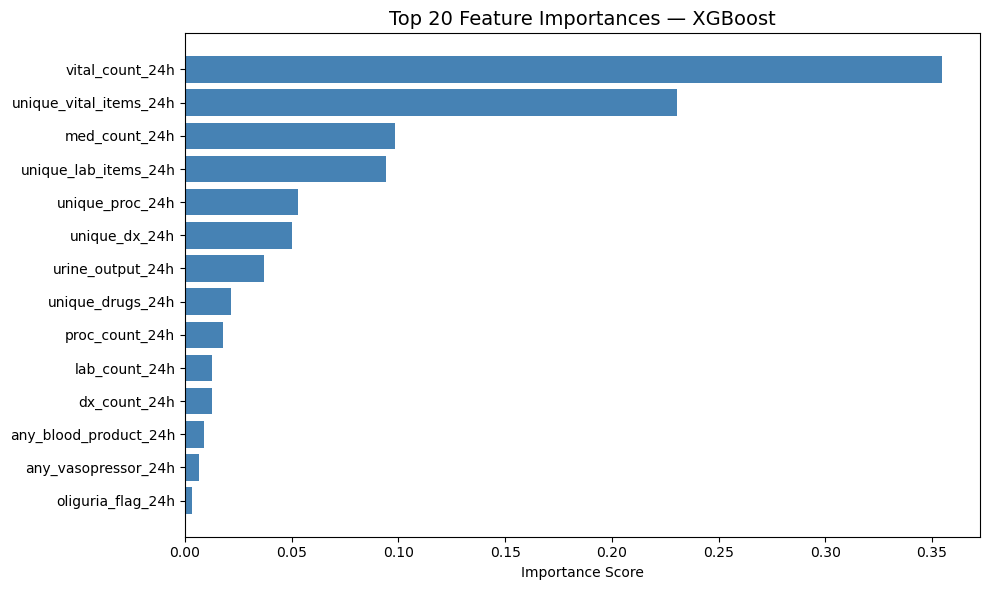

Saved PNG to: lightgbm_feature_importance.png


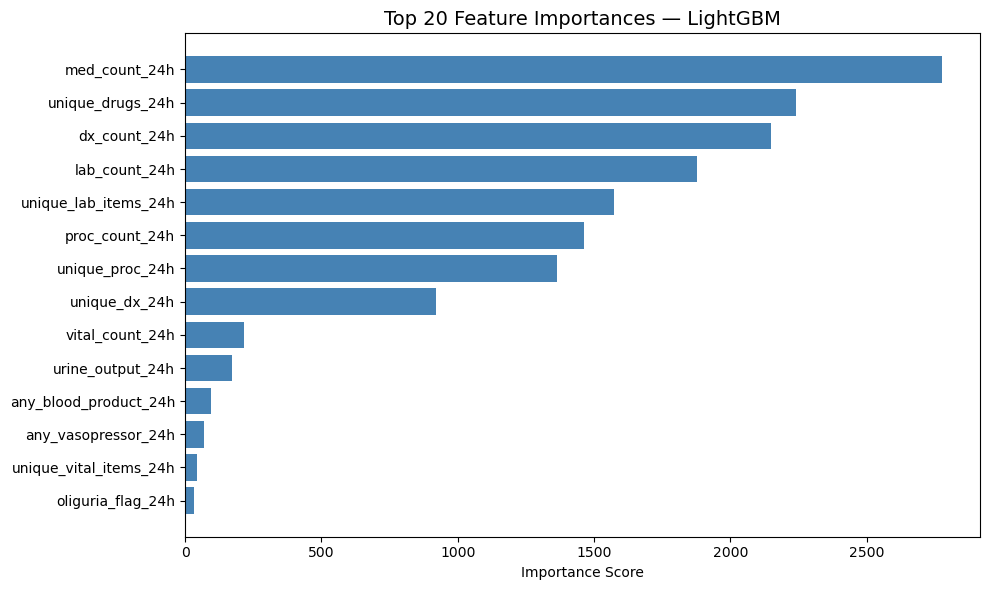

Saved PNG to: catboost_feature_importance.png


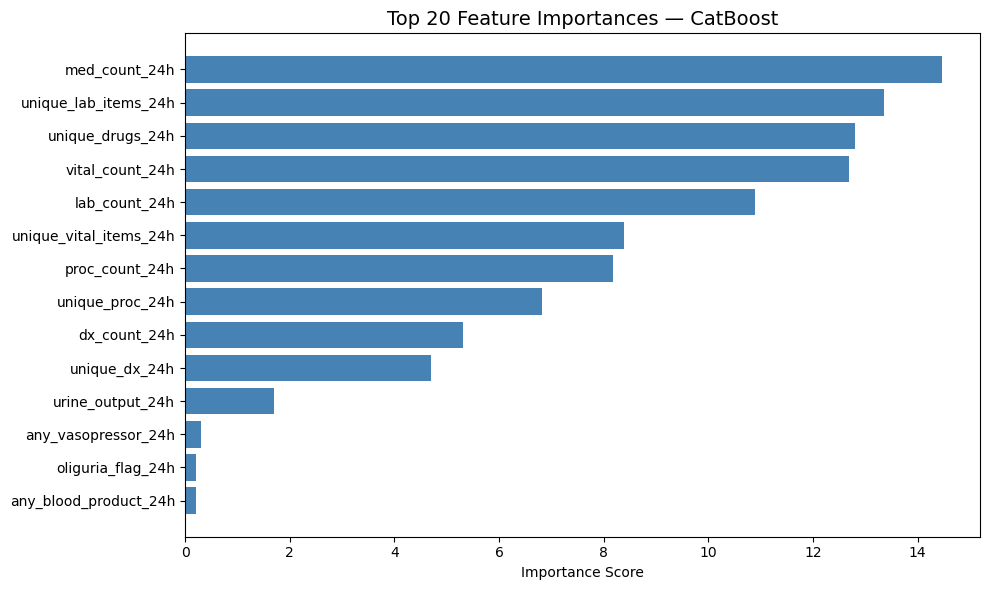

,feature,importance
4,med_count_24h,14.467096
1,unique_lab_items_24h,13.359546
5,unique_drugs_24h,12.793929
2,vital_count_24h,12.679538
0,lab_count_24h,10.888078
3,unique_vital_items_24h,8.383435
8,proc_count_24h,8.183306
9,unique_proc_24h,6.813060
6,dx_count_24h,5.308187
7,unique_dx_24h,4.704817


In [96]:
feature_names = X_train.columns

plot_feature_importance(
    xgb_model,
    feature_names,
    model_name="XGBoost",
    save_path="xgboost_feature_importance.png"
)

plot_feature_importance(
    lgb_model,
    feature_names,
    model_name="LightGBM",
    save_path="lightgbm_feature_importance.png"
)

plot_feature_importance(
    cat_model,
    feature_names,
    model_name="CatBoost",
    save_path="catboost_feature_importance.png"
)


Saved: shap_summary_bar.png
Saved: shap_beeswarm.png


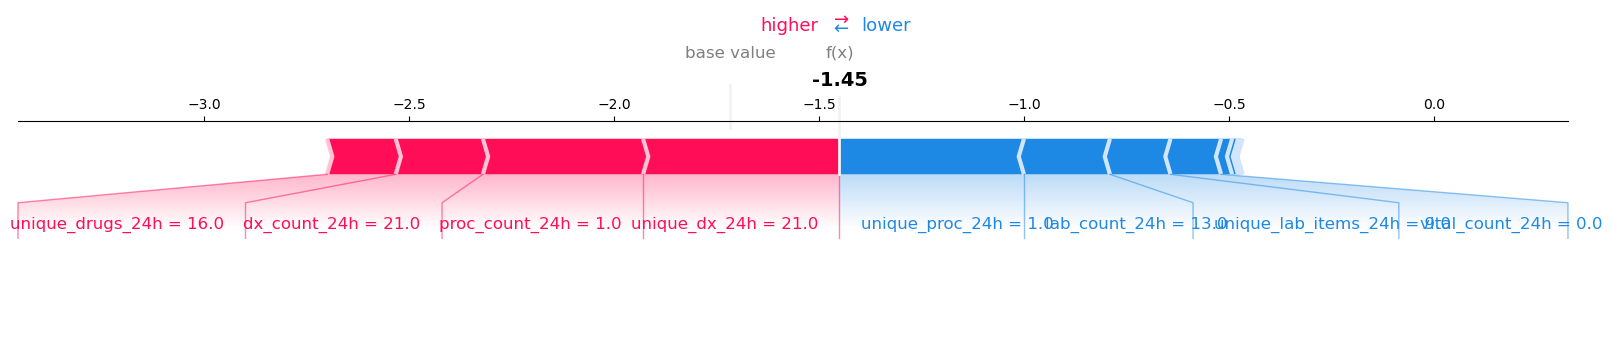

Saved: shap_force_patient10.png
Saved: shap_dependence_lab_count_24h.png
Saved: shap_dependence_unique_lab_items_24h.png
Saved: shap_dependence_vital_count_24h.png
Saved: shap_dependence_unique_vital_items_24h.png
Saved: shap_dependence_med_count_24h.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [97]:
import shap
import matplotlib.pyplot as plt

# =========================================================
# 1. Create SHAP explainer for XGBoost
# =========================================================
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# =========================================================
# 2. GLOBAL FEATURE IMPORTANCE (summary bar plot)
# =========================================================
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_summary_bar.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: shap_summary_bar.png")

# =========================================================
# 3. GLOBAL FEATURE IMPACT (beeswarm plot)
# =========================================================
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_beeswarm.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: shap_beeswarm.png")

# =========================================================
# 4. SINGLE-PATIENT EXPLANATION (force plot)
# =========================================================
patient_index = 10  # change as needed

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[patient_index, :],
    X_test.iloc[patient_index, :],
    matplotlib=True
)

plt.tight_layout()
plt.savefig("shap_force_patient10.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: shap_force_patient10.png")

# =========================================================
# 5. DEPENDENCE PLOTS (for top features)
# =========================================================
top_features = X_test.columns[:5]  # or manually pick

for feature in top_features:
    plt.figure()
    shap.dependence_plot(feature, shap_values, X_test, show=False)
    plt.tight_layout()
    plt.savefig(f"shap_dependence_{feature}.png", dpi=300, bbox_inches="tight")
    plt.close()
    print(f"Saved: shap_dependence_{feature}.png")


25th percentile: 0.0038624406
50th percentile: 0.023497134
75th percentile: 0.12151098
Index for 25th percentile: 1039
Index for 50th percentile: 1908
Index for 75th percentile: 4264


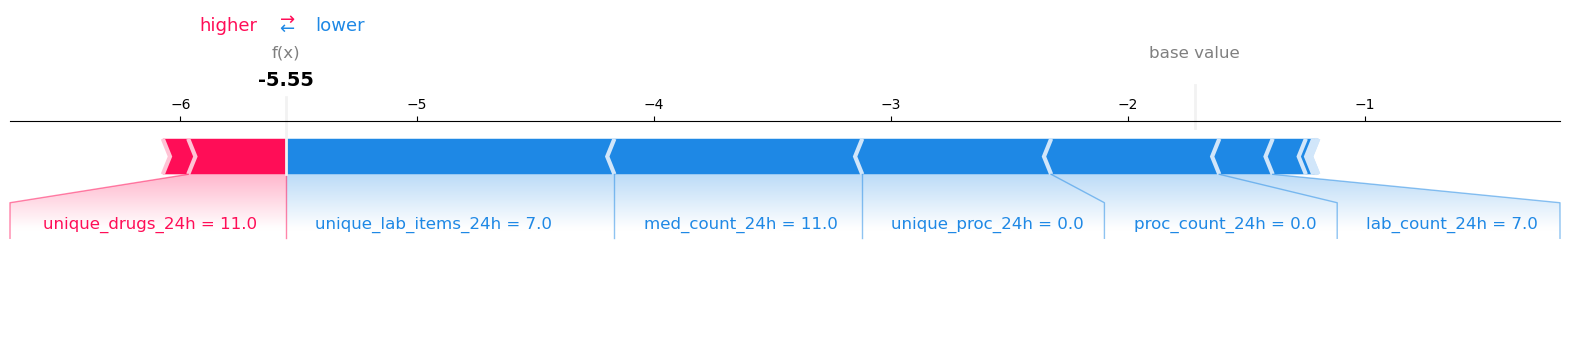

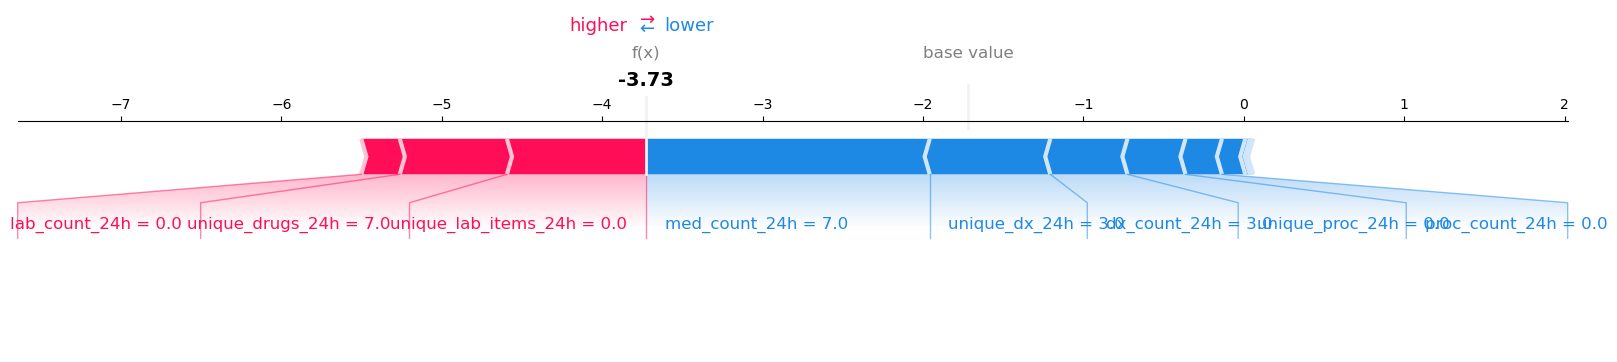

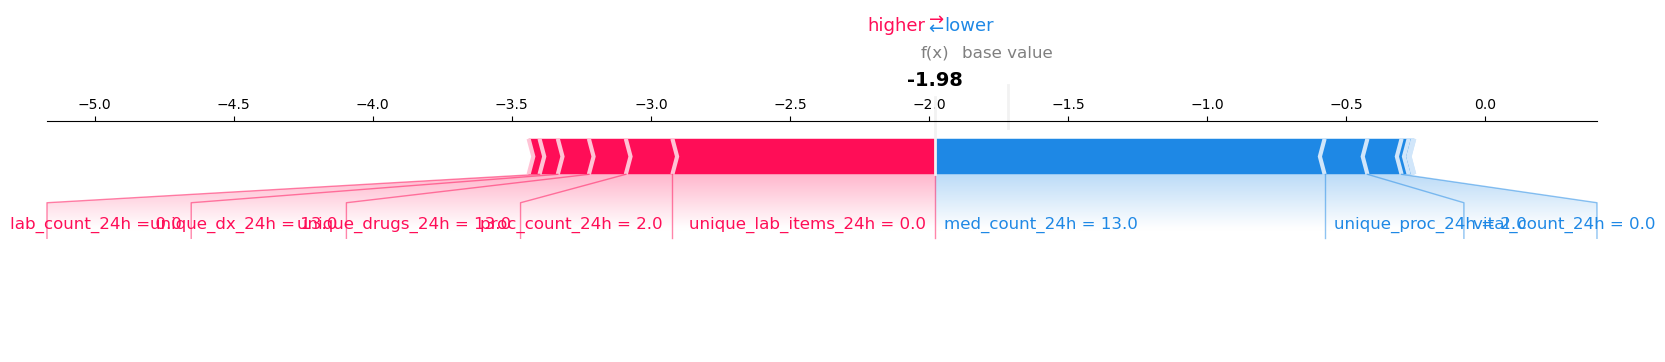


--- 25th percentile patient SHAP values ---
unique_drugs_24h          0.413994
unique_dx_24h             0.107246
oliguria_flag_24h        -0.000392
any_vasopressor_24h      -0.001454
any_blood_product_24h    -0.002506
dx_count_24h             -0.002747
urine_output_24h         -0.014438
unique_vital_items_24h   -0.031056
vital_count_24h          -0.140131
lab_count_24h            -0.225313
proc_count_24h           -0.709796
unique_proc_24h          -0.797420
med_count_24h            -1.046288
unique_lab_items_24h     -1.385190
dtype: float32

--- 50th percentile patient SHAP values ---
unique_lab_items_24h      0.866331
unique_drugs_24h          0.667872
lab_count_24h             0.240017
oliguria_flag_24h        -0.000409
any_vasopressor_24h      -0.001433
any_blood_product_24h    -0.002513
urine_output_24h         -0.014939
unique_vital_items_24h   -0.028222
vital_count_24h          -0.145711
proc_count_24h           -0.227044
unique_proc_24h          -0.361886
dx_count_24h        

In [98]:
import numpy as np
import shap

# =========================================================
# 1. Compute predicted probabilities for XGBoost
# =========================================================
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# =========================================================
# 2. Compute percentiles
# =========================================================
p25 = np.percentile(xgb_proba, 25)
p50 = np.percentile(xgb_proba, 50)
p75 = np.percentile(xgb_proba, 75)

print("25th percentile:", p25)
print("50th percentile:", p50)
print("75th percentile:", p75)

# =========================================================
# 3. Find the closest patient to each percentile
# =========================================================
idx_25 = (np.abs(xgb_proba - p25)).argmin()
idx_50 = (np.abs(xgb_proba - p50)).argmin()
idx_75 = (np.abs(xgb_proba - p75)).argmin()

print("Index for 25th percentile:", idx_25)
print("Index for 50th percentile:", idx_50)
print("Index for 75th percentile:", idx_75)

# =========================================================
# 4. Build SHAP explainer
# =========================================================
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# =========================================================
# 5. SHAP force plots for the three case studies
# =========================================================
# Moderate-low risk (25th percentile)
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_25, :],
    X_test.iloc[idx_25, :],
    matplotlib=True
)

# Average risk (50th percentile)
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_50, :],
    X_test.iloc[idx_50, :],
    matplotlib=True
)

# Moderate-high risk (75th percentile)
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_75, :],
    X_test.iloc[idx_75, :],
    matplotlib=True
)

# =========================================================
# 6. Optional: print the feature contributions numerically
# =========================================================
print("\n--- 25th percentile patient SHAP values ---")
print(pd.Series(shap_values[idx_25], index=X_test.columns).sort_values(ascending=False))

print("\n--- 50th percentile patient SHAP values ---")
print(pd.Series(shap_values[idx_50], index=X_test.columns).sort_values(ascending=False))

print("\n--- 75th percentile patient SHAP values ---")
print(pd.Series(shap_values[idx_75], index=X_test.columns).sort_values(ascending=False))


In [99]:
print("\n--- 75th percentile patient SHAP values ---")
print(pd.Series(shap_values[idx_75], index=X_test.columns).sort_values(ascending=False))


--- 75th percentile patient SHAP values ---
unique_lab_items_24h      0.944598
proc_count_24h            0.167391
unique_drugs_24h          0.132850
unique_dx_24h             0.111756
lab_count_24h             0.065621
dx_count_24h              0.039272
oliguria_flag_24h        -0.000393
any_vasopressor_24h      -0.001457
any_blood_product_24h    -0.002838
urine_output_24h         -0.015462
unique_vital_items_24h   -0.025570
vital_count_24h          -0.122718
unique_proc_24h          -0.153983
med_count_24h            -1.400170
dtype: float32


In [112]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# ============================================================
# ICU DATASET
# ============================================================

df_icu = pd.read_parquet("icu_24h_dataset.parquet")

X_icu = df_icu.drop(columns=["ever_in_icu", "hadm_id"])
y_icu = df_icu["ever_in_icu"]

# Train/test split
X_train_icu, X_test_icu, y_train_icu, y_test_icu = train_test_split(
    X_icu, y_icu, test_size=0.2, random_state=42, stratify=y_icu
)

# ============================================================
# ICU MODEL
# ============================================================

xgb_icu = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

xgb_icu.fit(X_train_icu, y_train_icu)

# Predicted probabilities
y_prob_icu = xgb_icu.predict_proba(X_test_icu)[:, 1]

# Threshold for ICU
best_thr_icu = 0.50
y_pred_icu = (y_prob_icu >= best_thr_icu).astype(int)

print("ICU model variables successfully created.")


ICU model variables successfully created.


In [113]:
import os
os.makedirs("appendix_c_outputs", exist_ok=True)

def save_classification_outputs(model_name, y_true, y_prob, threshold):
    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f"{model_name} — ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"appendix_c_outputs/{model_name}_ROC.png")
    plt.close()

    # PR
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(5,4))
    plt.plot(recall, precision)
    plt.title(f"{model_name} — Precision–Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.tight_layout()
    plt.savefig(f"appendix_c_outputs/{model_name}_PR.png")
    plt.close()

    # Confusion matrix
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{model_name} — Confusion Matrix (thr={threshold})")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"appendix_c_outputs/{model_name}_CM.png")
    plt.close()

    # Classification report
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report.to_csv(f"appendix_c_outputs/{model_name}_Classification_Report.csv")

    # Threshold sweep (0.01–0.99)
    rows = []
    for thr in np.linspace(0.01, 0.99, 99):
        y_thr = (y_prob >= thr).astype(int)
        cm_thr = confusion_matrix(y_true, y_thr)
        tn, fp, fn, tp = cm_thr.ravel()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0
        rows.append({
            "threshold": thr,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "precision": prec,
            "recall": rec
        })
    df_thr = pd.DataFrame(rows)
    df_thr.to_csv(f"appendix_c_outputs/{model_name}_Threshold_Sweep.csv", index=False)

    print(f"{model_name}: saved ROC, PR, CM, report, threshold sweep.")


In [118]:
# Readmission
save_classification_outputs(
    model_name="Readmission_XGB",
    y_true=y_test_readm,
    y_prob=y_prob_readm,
    threshold=best_thr_readm
)

# ICU
save_classification_outputs(
    model_name="ICU_XGB",
    y_true=y_test_icu,
    y_prob=y_prob_icu,
    threshold=best_thr_icu
)



from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# MAE
mae = mean_absolute_error(y_test_los, y_pred_los)

# RMSE (manual square root for older sklearn versions)
mse = mean_squared_error(y_test_los, y_pred_los)
rmse = np.sqrt(mse)

plt.figure(figsize=(5,4))
sns.histplot(y_test_los - y_pred_los, kde=True)
plt.title(f"LOS Model — Error Distribution (MAE={mae:.2f}, RMSE={rmse:.2f})")
plt.xlabel("Prediction Error (days)")
plt.tight_layout()
plt.savefig("appendix_c_outputs/LOS_Error_Distribution.png")
plt.close()

print("LOS metrics computed successfully:")
print("MAE:", mae)
print("RMSE:", rmse)


print("All Appendix C outputs generated into 'appendix_c_outputs' folder.")

Readmission_XGB: saved ROC, PR, CM, report, threshold sweep.
ICU_XGB: saved ROC, PR, CM, report, threshold sweep.
LOS metrics computed successfully:
MAE: 1.4128206587011125
RMSE: 3.207503043417708
All Appendix C outputs generated into 'appendix_c_outputs' folder.


<Figure size 1200x400 with 0 Axes>

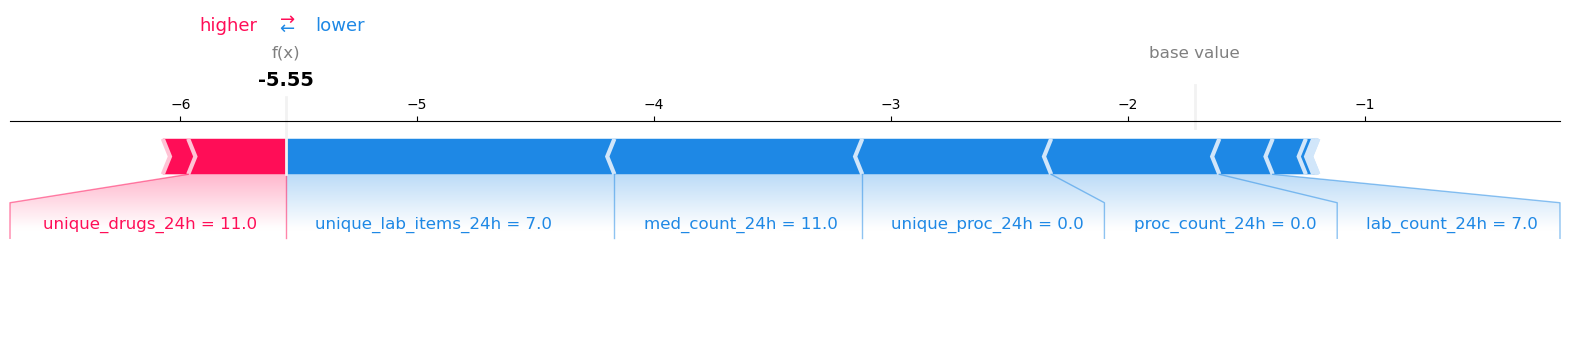

<Figure size 1200x400 with 0 Axes>

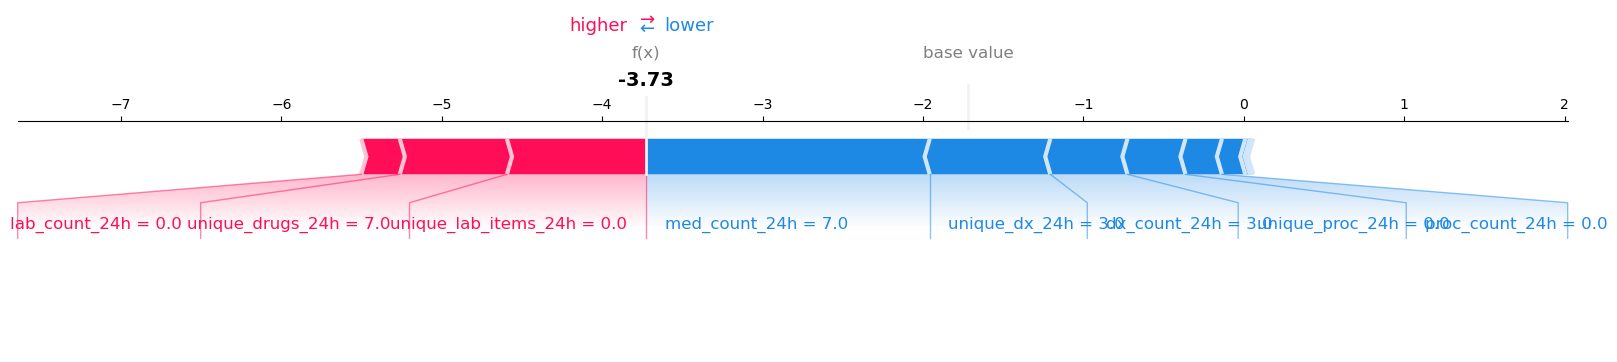

<Figure size 1200x400 with 0 Axes>

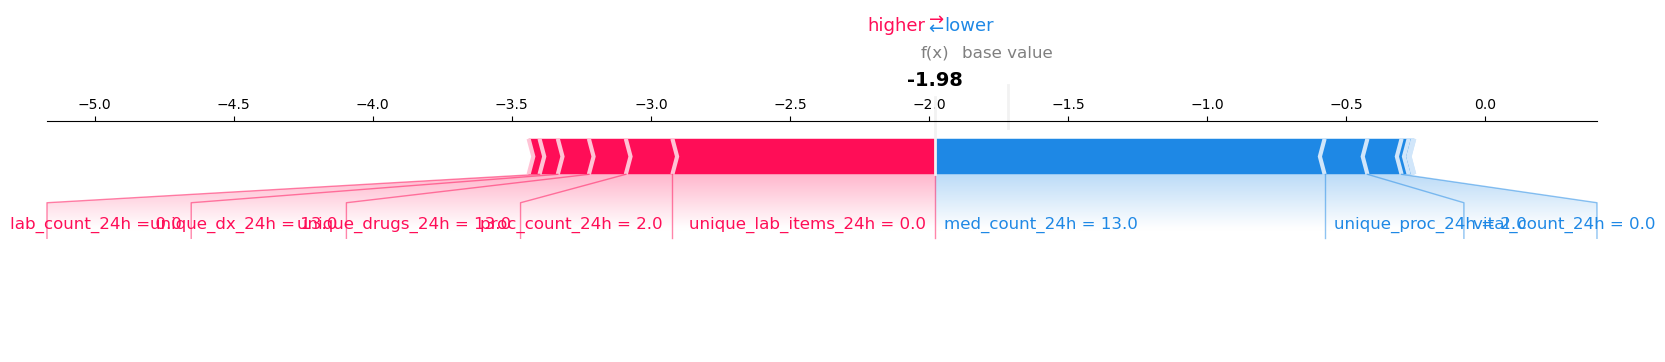

Saved SHAP force plots for 25th, 50th, 75th percentile patients.
All Appendix E SHAP plots saved successfully.


In [119]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ============================================================
# 0. Create output folder
# ============================================================
os.makedirs("appendix_e_outputs", exist_ok=True)

# ============================================================
# 1. SHAP EXPLAINER FOR ICU MODEL
# ============================================================
explainer_icu = shap.TreeExplainer(xgb_icu)
shap_values_icu = explainer_icu.shap_values(X_test_icu)

# ============================================================
# 2. YOUR CASE STUDY INDICES
# ============================================================
case_indices = {
    "25th_percentile": 1039,
    "50th_percentile": 1908,
    "75th_percentile": 4264
}

# ============================================================
# 3. GENERATE FORCE PLOTS FOR EACH CASE STUDY
# ============================================================
shap.initjs()

for label, idx in case_indices.items():
    x_case = X_test_icu.iloc[idx:idx+1]
    shap_case = shap_values_icu[idx:idx+1]

    plt.figure(figsize=(12, 4))
    shap.force_plot(
        explainer_icu.expected_value,
        shap_case,
        x_case,
        matplotlib=True
    )
    plt.tight_layout()
    plt.savefig(f"appendix_e_outputs/ICU_SHAP_Force_{label}.png",
                dpi=300, bbox_inches="tight")
    plt.close()

print("Saved SHAP force plots for 25th, 50th, 75th percentile patients.")

# ============================================================
# 4. GLOBAL SUMMARY PLOT (TOP 20 FEATURES)
# ============================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_icu,
    X_test_icu,
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig("appendix_e_outputs/ICU_SHAP_Summary_Top20.png",
            dpi=300, bbox_inches="tight")
plt.close()

# ============================================================
# 5. GLOBAL BAR PLOT (TOP 20 FEATURES)
# ============================================================
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_icu,
    X_test_icu,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.tight_layout()
plt.savefig("appendix_e_outputs/ICU_SHAP_Bar_Top20.png",
            dpi=300, bbox_inches="tight")
plt.close()

print("All Appendix E SHAP plots saved successfully.")
